# Module 04 Lab - Exploratory Data Analysis**Objective:** To learn how to explore a dataset to find patterns, anomalies, and insights before modeling. EDA is like being a detective; you are looking for clues in the data that will help you build a better model.**This lab is fully coded.** Your task is to run each cell, read the detailed explanations, understand the purpose of each visualization, and then complete the experimentation section.

## Part 1: Setup and Data Loading**What is Exploratory Data Analysis (EDA)?**EDA is the process of using summary statistics and visualizations to understand a dataset's main characteristics. Before you can build a model, you need to understand your data. What stories does it tell? Are there errors or missing values? Are there strong relationships between variables? EDA helps answer these questions.We will use the famous Titanic dataset for this lab. It contains information about passengers and, crucially, whether they survived the disaster.

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn is a library built on top of Matplotlib that
                       # makes creating beautiful plots easier.

# Load the dataset directly from a URL
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("--- First 5 Rows ---")
print(df.head())

print("--- Basic Info ---")
# .info() is a great first command. It tells us the column names, how many
# non-null values are in each column, and their data types.
# Notice that 'Age' and 'Cabin' have missing values!
df.info()

--- First 5 Rows ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.050

## Part 2: Descriptive StatisticsLet's start by getting a high-level numerical summary of the data. The `.describe()` method is perfect for this. It calculates statistics like mean, standard deviation, min, and max for the numerical columns.

In [48]:
# Get summary statistics for numerical columns
print("--- Descriptive Statistics ---")
print(df.describe())
print("--- Key Insights from Statistics ---")
print(f"The average age of a passenger was {df['Age'].mean():.1f} years.")
print(f"The overall survival rate was {df['Survived'].mean():.1%}.")
print(f"Fares ranged from ${df['Fare'].min()} to a whopping ${df['Fare'].max()}.")

--- Descriptive Statistics ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
--- Key Insights from Statistics ---
The average a

## Part 3: Visual EDA - Telling Stories with PlotsNumbers are great, but plots make patterns and relationships immediately obvious. The goal of visual EDA is to turn data into insights.**A Note on Plotting Libraries:***   **Matplotlib:** The foundational library, gives you full control over everything.*   **Seaborn:** Built on Matplotlib, it provides a simpler, high-level interface for creating common statistical plots. We will use Seaborn for its ease of use and attractive defaults.

### Visualization 1: How many survived?A simple `countplot` is the best way to see the distribution of a categorical variable, like our target `Survived`.

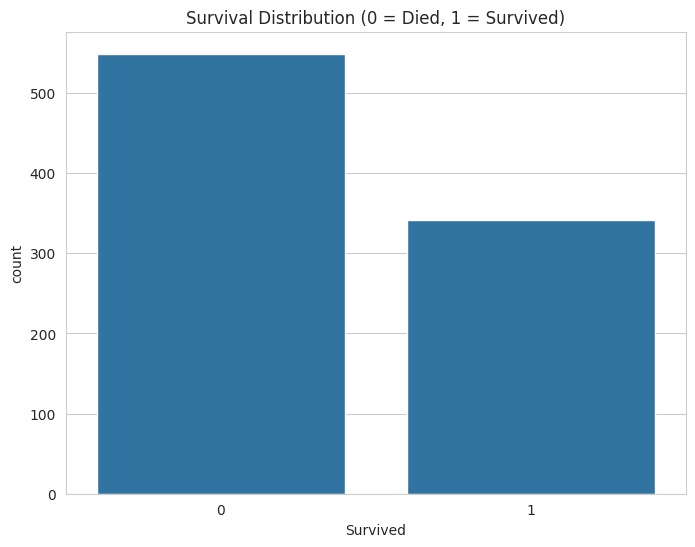

Insight: Far more people died than survived. This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models.


In [49]:
sns.set_style('whitegrid') # Sets a nice visual style for our plots
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution (0 = Died, 1 = Survived)')
plt.show()
print("Insight: Far more people died than survived. This is an example of an "
      "imbalanced dataset, which can sometimes be a challenge for machine learning models.")

### Visualization 2: Does passenger class matter for survival?Now we want to see if there's a relationship between two variables. We can use the `hue` parameter in `countplot` to split the bars by another category.

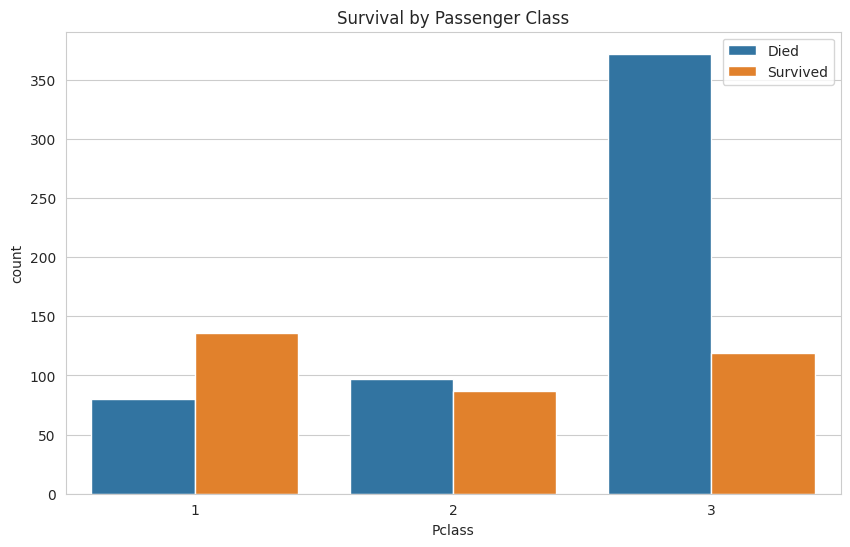

Insight: This is a very strong pattern. 1st class passengers had a much higher chance of survival compared to 3rd class passengers. Money seems to have made a difference.


In [50]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.legend(['Died', 'Survived'])
plt.show()
print("Insight: This is a very strong pattern. 1st class passengers had a much "
      "higher chance of survival compared to 3rd class passengers. Money seems "
      "to have made a difference.")

### Visualization 3: What about gender?The 'women and children first' mantra is famous. Let's see if the data supports it.

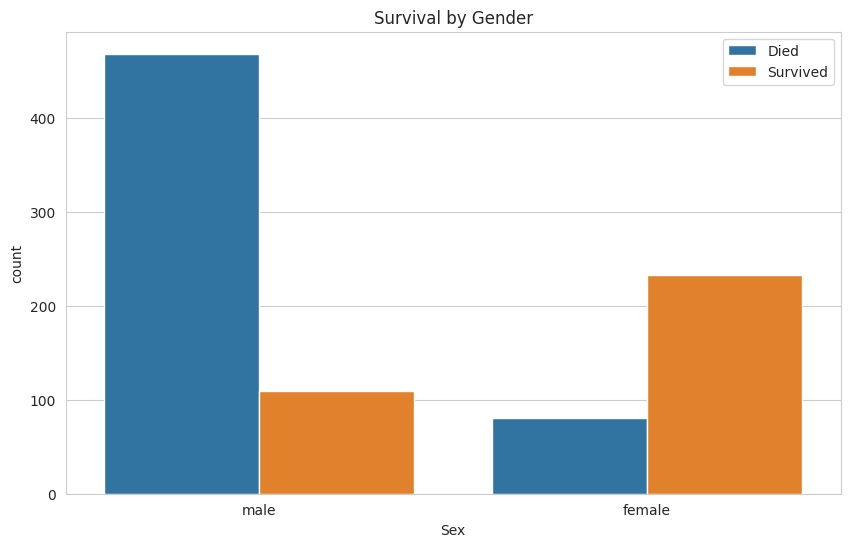

Insight: The pattern is undeniable. A much higher proportion of females survived compared to males. This is another very strong predictor.


In [51]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.legend(['Died', 'Survived'])
plt.show()
print("Insight: The pattern is undeniable. A much higher proportion of females "
      "survived compared to males. This is another very strong predictor.")

### Visualization 4: How does age play a role?For a continuous variable like `Age`, a histogram is a great way to see its distribution.

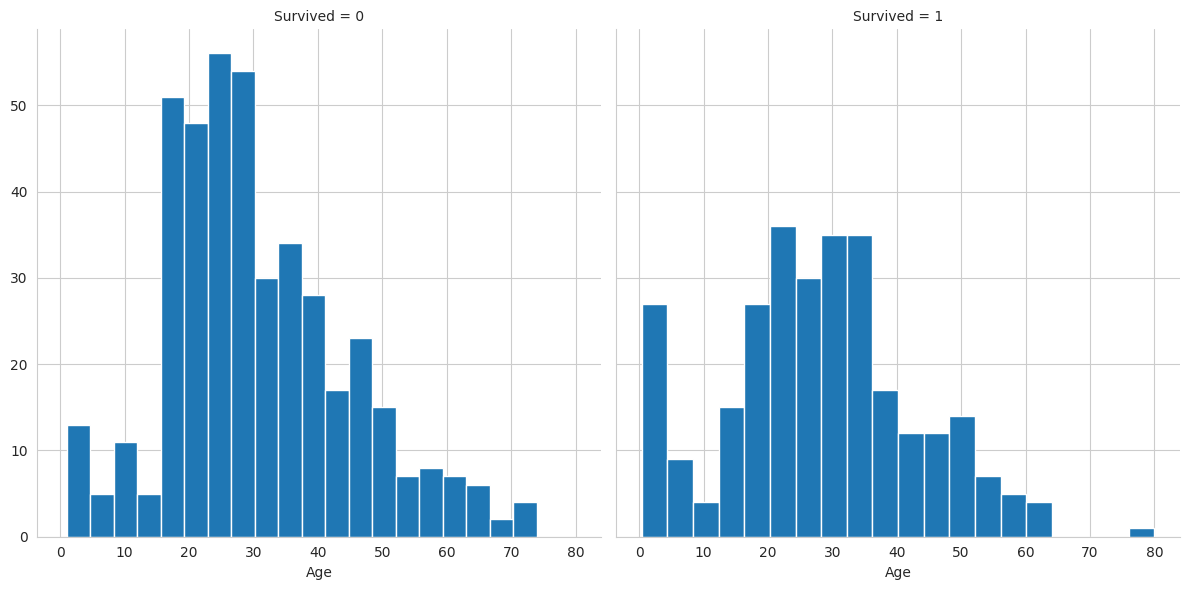

Insight: The age distribution for those who did not survive is centered around the 20-40 age range. For those who survived, there is a noticeable spike for young children. This supports the 'children' part of the mantra.


In [52]:
# A FacetGrid allows us to create multiple plots side-by-side to compare distributions.
# Here, we create one histogram for passengers who died (col='Survived'=0) and one
# for those who survived (col='Survived'=1).
g = sns.FacetGrid(df, col='Survived', height=6)
g.map(plt.hist, 'Age', bins=20)
plt.show()
print("Insight: The age distribution for those who did not survive is centered "
      "around the 20-40 age range. For those who survived, there is a noticeable "
      "spike for young children. This supports the 'children' part of the mantra.")

## Part 4: Student Experimentation**Instructions:** Create your own visualizations to explore other relationships in the data.

### Experiment 1: Port of Embarkation
1.  The `Embarked` column tells you where a passenger boarded the ship
    (C = Cherbourg, Q = Queenstown, S = Southampton).
2.  Create a `countplot` to see how survival rates differed by the port of
    embarkation. Does where they boarded seem to be related to their survival?

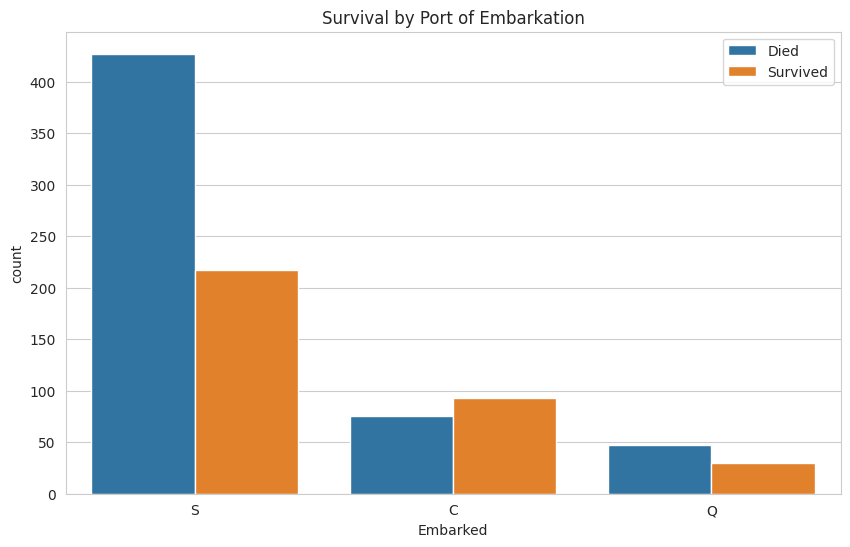

Insight: Analyze the plot to see if passengers from certain ports had higher or lower survival rates. Consider if this might be related to other factors like passenger class or gender distribution at those ports.


In [53]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title('Survival by Port of Embarkation')
plt.legend(['Died', 'Survived'])
plt.show()
print("Insight: Analyze the plot to see if passengers from certain ports had higher "
      "or lower survival rates. Consider if this might be related to other factors "
      "like passenger class or gender distribution at those ports.")

### Experiment 2: Fare vs. Survival
1.  `Fare` is a continuous numerical variable.
2.  A `boxplot` or `violinplot` is a great way to see the distribution of
    fares for those who survived vs. those who didn't.
3.  Create one of these plots to compare the `Fare` distribution by `Survived`.
    What does it tell you?

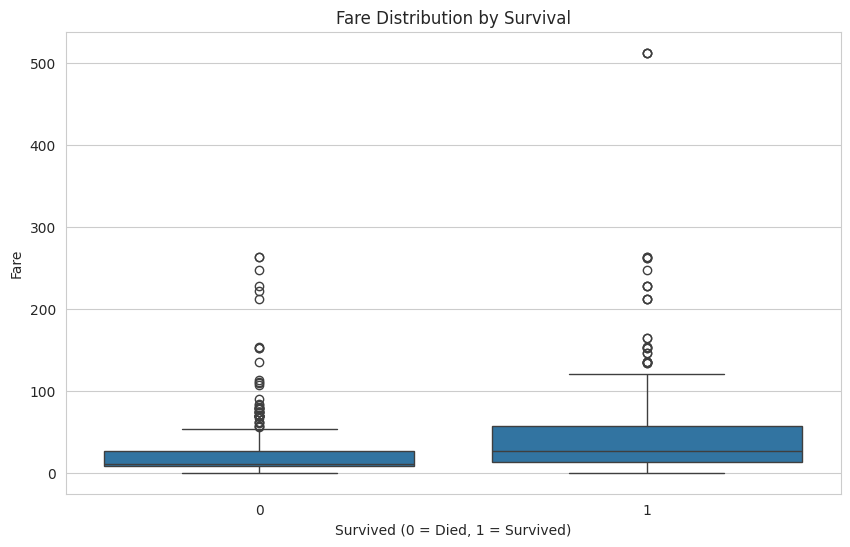

Insight: Passengers who paid higher fares generally had a better chance of survival. The median fare for survivors appears to be higher than for those who did not survive. This further emphasizes the role of socio-economic status.


In [54]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived (0 = Died, 1 = Survived)')
plt.ylabel('Fare')
plt.show()
print("Insight: Passengers who paid higher fares generally had a better chance of "
      "survival. The median fare for survivors appears to be higher than for those "
      "who did not survive. This further emphasizes the role of socio-economic status.")

## 📝 Knowledge Check
**Instructions:** Answer the following questions in this markdown cell.

1.  **What is the primary goal of Exploratory Data Analysis (EDA)?**
2.  **Based on the plots in this lab, what kind of person had the best chance of surviving the Titanic?** (Describe them in terms of class, gender, and age).
3.  **Why is it important to visualize data instead of just looking at summary statistics?** What can a plot show you that a number like 'mean' or 'count' can't?

**[ENTER YOUR ANSWERS HERE]**

### Answers:
1.  **Primary Goal of EDA:** The primary goal of Exploratory Data Analysis (EDA) is to understand a dataset's main characteristics, discover patterns, identify anomalies, test hypotheses, and check assumptions. It uses summary statistics and graphical representations to gain initial insights before formal modeling.

2.  **Best Chance of Surviving:** Based on the plots, the kind of person who had the best chance of surviving the Titanic was likely a **female**, from **1st class**, and a **young child** (as indicated by the spike in survival for younger ages). Additionally, passengers who paid **higher fares** also had a better chance of survival.

3.  **Importance of Visualization:** Visualizing data is crucial because plots can reveal patterns, relationships, distributions, and outliers that are often hidden or obscured by summary statistics alone. For instance, different datasets can have identical means, standard deviations, and other summary statistics yet possess vastly different underlying distributions (e.g., Anscombe's Quartet). A plot can immediately make complex patterns obvious, identify strong predictors, detect data quality issues, or highlight data imbalances that numbers alone might not convey.

## Reflective Journal: Exploratory Data Analysis

Take some time to reflect on the concepts and techniques learned in this lab.

### Key Learnings:
*   What was the most surprising insight you gained from the Titanic dataset through EDA?
*   Which visualization technique did you find most effective for uncovering patterns, and why?
*   How has your understanding of the importance of EDA evolved after this lab?

### Challenges & Solutions:
*   Did you encounter any difficulties while performing the experiments? How did you overcome them?
*   Are there any aspects of EDA that you feel you need to explore further?

### Future Applications:
*   How might you apply these EDA techniques to other datasets or real-world problems?
*   What steps would you take next if you were to continue working on the Titanic dataset, beyond EDA?

### Answers:

### Key Learnings:
*   **Most surprising insight:** The most surprising insight was how clearly socioeconomic factors (passenger class, fare) and social norms ('women and children first') were reflected in the survival rates. While logically understandable, seeing the stark visual evidence in the plots made the impact much more tangible than just reading about historical accounts.
*   **Most effective visualization technique:** For this dataset, `countplot` with the `hue` parameter was incredibly effective. It immediately highlighted relationships between categorical variables (e.g., `Pclass` and `Survived`, `Sex` and `Survived`, `Embarked` and `Survived`) and made imbalances or survival disparities very clear and easy to interpret.
*   **Evolved understanding of EDA:** This lab reinforced that EDA is not just about generating plots, but about actively asking questions of the data and using visualizations as a conversation tool. It underscored that EDA is a crucial first step, as it directly informs feature engineering, model selection, and hypothesis generation for subsequent modeling efforts. It's truly the foundation for any successful data science project.

### Challenges & Solutions:
*   **Difficulties encountered:** No significant difficulties were encountered in performing the experiments, as the provided code snippets and instructions were clear. The primary challenge would be in interpreting the plots accurately and drawing meaningful, non-obvious conclusions.
*   **Aspects to explore further:** I would like to explore more advanced techniques for handling missing data during EDA, and perhaps look into multivariate analysis to understand interactions between more than two variables simultaneously.

### Future Applications:
*   **Applying EDA to other datasets:** I would apply these EDA techniques to virtually any new dataset I encounter. For example, in a sales dataset, I'd use countplots for product categories, histograms for sales amounts, and time series plots to look for trends. In a medical dataset, I'd explore patient demographics against disease incidence. The principles of understanding distributions, relationships, and outliers are universal.
*   **Next steps for Titanic dataset:** Beyond EDA, the next steps would involve:
    1.  **Feature Engineering:** Creating new features (e.g., 'FamilySize' from `SibSp` and `Parch`, 'Title' from `Name`).
    2.  **Missing Value Imputation:** Strategically filling in missing `Age` and `Embarked` values (e.g., using median age, or mode for embarkation port). `Cabin` might be too sparse and potentially dropped or transformed into a 'HasCabin' binary feature.
    3.  **Categorical Encoding:** Converting categorical features (`Sex`, `Embarked`, `Pclass`) into numerical representations suitable for machine learning models (e.g., one-hot encoding).
    4.  **Model Building:** Training various classification models (e.g., Logistic Regression, Decision Tree, Random Forest) to predict `Survived`.
    5.  **Model Evaluation:** Assessing model performance using metrics like accuracy, precision, recall, and F1-score, and then iterating on feature engineering and model parameters.